In [12]:
# EXP_v2 version of EXP027/notebook/analyze_q_values_top_bottom.ipynb
# For each theta in {-3, -2, -1, 0, 1, 2, 3}, forward the trained DQN with
# state=[theta] and inspect the top-5% / bottom-5% items ranked by Q value.
# Uses the 2PL bank (a, b) and outputs SEPARATE figures per DQN prior variant.
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "EXP_v2" / "data" / "theta_true").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


ROOT = find_project_root()
EXP_V2_DIR = ROOT / "EXP_v2"
MODEL_DIR = EXP_V2_DIR / "models"
RESULTS_DIR = EXP_V2_DIR / "results"

device = torch.device("cpu")

# Config aligned with EXP_v2 DQN research_param training.
INPUT_SIZE = 1
FIRST_HIDDEN = 50
SECOND_HIDDEN = 30
DROPOUT_RATE = 0.0

BANK_ID = 1
N_ITEMS = 100
ACTION_SPACE = N_ITEMS

MODELS_CFG = {
    "DQN_normal_fp32": {"prior": "normal",  "epsilon": 0.5, "gamma": 0.5, "dtype": "fp32", "suffix": ""},
    "DQN_normal_fp64": {"prior": "normal",  "epsilon": 0.3, "gamma": 0.0, "dtype": "fp64", "suffix": "_fp64"},
    "DQN_uniform":     {"prior": "uniform", "epsilon": 0.3, "gamma": 0.0, "dtype": "fp32", "suffix": ""},
}

THETAS = [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
TOP_FRAC = 0.05  # top 5% and bottom 5% of Q values

print(f"Project root : {ROOT}")
print(f"Model dir    : {MODEL_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Bank         : 2pl_{BANK_ID}, {N_ITEMS} items")
print(f"Models       : {list(MODELS_CFG.keys())}")
print(f"Thetas       : {THETAS}")
print(f"Top/bottom % : {TOP_FRAC:.0%}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Model dir    : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/models
Results dir  : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results
Bank         : 2pl_1, 100 items
Models       : ['DQN_normal_fp32', 'DQN_normal_fp64', 'DQN_uniform']
Thetas       : [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
Top/bottom % : 5%


In [13]:
class Net(nn.Module):
    def __init__(self, input_size, first_hidden, second_hidden, action_space, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_size, first_hidden)
        self.fc2 = nn.Linear(first_hidden, second_hidden)
        self.out = nn.Linear(second_hidden, action_space)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(self.fc1(x))
        x = F.relu(x)
        x = self.dropout(self.fc2(x))
        x = F.relu(x)
        return self.out(x)


def load_model(path: Path, dtype_str: str = "fp32") -> Net:
    model = Net(INPUT_SIZE, FIRST_HIDDEN, SECOND_HIDDEN, ACTION_SPACE, DROPOUT_RATE).to(device)
    if dtype_str == "fp64":
        model = model.double()
    state_dict = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def FI_2pl(item_para: np.ndarray, theta: float, D: float = 1.0) -> np.ndarray:
    """2PL Fisher information: D^2 * a^2 * p * (1-p)."""
    a = item_para[:, 0]
    b = item_para[:, 1]
    p = 1.0 / (1.0 + np.exp(-D * a * (theta - b)))
    return D**2 * a**2 * p * (1.0 - p)


bank_path = EXP_V2_DIR / "data" / f"2PL_{N_ITEMS}items" / f"item_bank_uncor_{BANK_ID}.csv"
item_bank_df = pd.read_csv(bank_path)[["a", "b"]]
item_bank = item_bank_df.to_numpy()[:N_ITEMS]
assert item_bank.shape == (N_ITEMS, 2), f"unexpected bank shape: {item_bank.shape}"

models = {}
for name, cfg in MODELS_CFG.items():
    path = MODEL_DIR / (
        f"dqn_{cfg['prior']}_2pl_{BANK_ID}_{N_ITEMS}items_"
        f"epsilon_{cfg['epsilon']}_gamma_{cfg['gamma']}_research_param{cfg['suffix']}.pt"
    )
    models[name] = load_model(path, dtype_str=cfg["dtype"])
    print(f"loaded {name:12s}: {path.name}")

print(f"\nitem bank : {item_bank.shape}  (from {bank_path.name})")

loaded DQN_normal_fp32: dqn_normal_2pl_1_100items_epsilon_0.5_gamma_0.5_research_param.pt
loaded DQN_normal_fp64: dqn_normal_2pl_1_100items_epsilon_0.3_gamma_0.0_research_param_fp64.pt
loaded DQN_uniform : dqn_uniform_2pl_1_100items_epsilon_0.3_gamma_0.0_research_param.pt

item bank : (100, 2)  (from item_bank_uncor_1.csv)


In [14]:
def q_values(model: Net, theta: float) -> np.ndarray:
    param_dtype = next(model.parameters()).dtype
    state = torch.tensor([[theta]], dtype=param_dtype, device=device)
    with torch.no_grad():
        q = model(state).cpu().numpy().flatten()
    return q


def describe_group(item_bank: np.ndarray, fi: np.ndarray, idx: np.ndarray) -> dict:
    subset = item_bank[idx]
    fi_subset = fi[idx]
    return {
        "n": len(idx),
        "a_mean": subset[:, 0].mean(),
        "a_std": subset[:, 0].std(ddof=1) if len(idx) > 1 else 0.0,
        "b_mean": subset[:, 1].mean(),
        "b_std": subset[:, 1].std(ddof=1) if len(idx) > 1 else 0.0,
        "FI_mean": fi_subset.mean(),
        "FI_median": np.median(fi_subset),
        "FI_max": fi_subset.max(),
        "FI_min": fi_subset.min(),
    }


def analyze(model: Net, theta: float, item_bank: np.ndarray, top_frac: float) -> dict:
    q = q_values(model, theta)
    fi = FI_2pl(item_bank, theta)

    k = max(1, int(round(len(q) * top_frac)))
    order = np.argsort(q)  # ascending
    bottom_idx = order[:k]
    top_idx = order[-k:]

    return {
        "top":    {**describe_group(item_bank, fi, top_idx),
                    "Q_mean": q[top_idx].mean(), "Q_min": q[top_idx].min(), "Q_max": q[top_idx].max()},
        "bottom": {**describe_group(item_bank, fi, bottom_idx),
                    "Q_mean": q[bottom_idx].mean(), "Q_min": q[bottom_idx].min(), "Q_max": q[bottom_idx].max()},
        "all_FI_mean": fi.mean(),
        "top_idx": top_idx,
        "bottom_idx": bottom_idx,
        "q": q,
        "fi": fi,
    }


records = []
raw_by_model_theta: dict[tuple[str, float], dict] = {}
for model_name, model in models.items():
    for theta in THETAS:
        result = analyze(model, theta, item_bank, TOP_FRAC)
        raw_by_model_theta[(model_name, theta)] = result
        for group in ("top", "bottom"):
            row = {"model": model_name, "theta": theta, "group": group}
            row.update(result[group])
            row["all_FI_mean"] = result["all_FI_mean"]
            records.append(row)

summary = pd.DataFrame(records)
summary_cols = [
    "model", "theta", "group", "n",
    "a_mean", "a_std", "b_mean", "b_std",
    "FI_mean", "FI_median", "FI_max", "FI_min", "all_FI_mean",
    "Q_mean", "Q_min", "Q_max",
]
summary = summary[summary_cols]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
output_csv = RESULTS_DIR / f"analysis_q_top_bottom_2pl_{BANK_ID}_{N_ITEMS}items.csv"
summary.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

with pd.option_context("display.max_rows", None, "display.width", 200):
    print(summary.to_string(index=False, float_format="{:.3f}".format))

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_top_bottom_2pl_1_100items.csv
          model  theta  group  n  a_mean  a_std  b_mean  b_std  FI_mean  FI_median  FI_max  FI_min  all_FI_mean  Q_mean  Q_min  Q_max
DQN_normal_fp32 -3.000    top  5   1.870  0.234  -0.419  0.478    0.037      0.046   0.053   0.002        0.044   1.103  1.031  1.174
DQN_normal_fp32 -3.000 bottom  5   0.426  0.210  -0.368  0.773    0.032      0.036   0.058   0.002        0.044   0.544  0.524  0.553
DQN_normal_fp32 -2.000    top  5   1.870  0.234  -0.419  0.478    0.193      0.219   0.288   0.021        0.117   1.110  1.043  1.178
DQN_normal_fp32 -2.000 bottom  5   0.426  0.210  -0.368  0.773    0.041      0.053   0.066   0.002        0.117   0.547  0.530  0.556
DQN_normal_fp32 -1.000    top  5   1.870  0.234  -0.419  0.478    0.600      0.669   0.817   0.189        0.225   1.119  1.056  1.188
DQN_normal_fp32 -1.000 bottom  5   0.373 

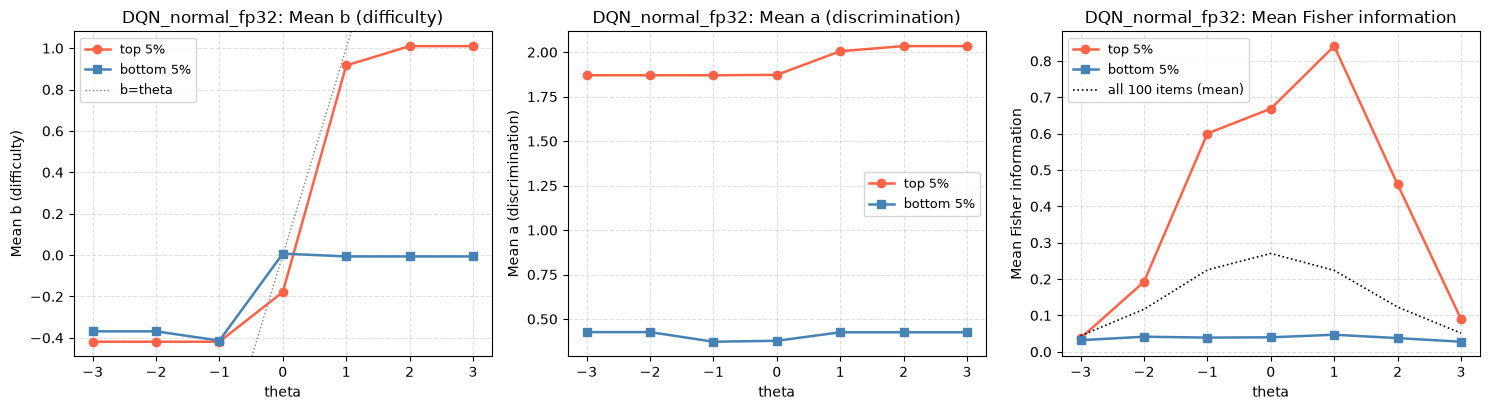

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_top_bottom_2pl_1_100items_DQN_normal_fp32.png


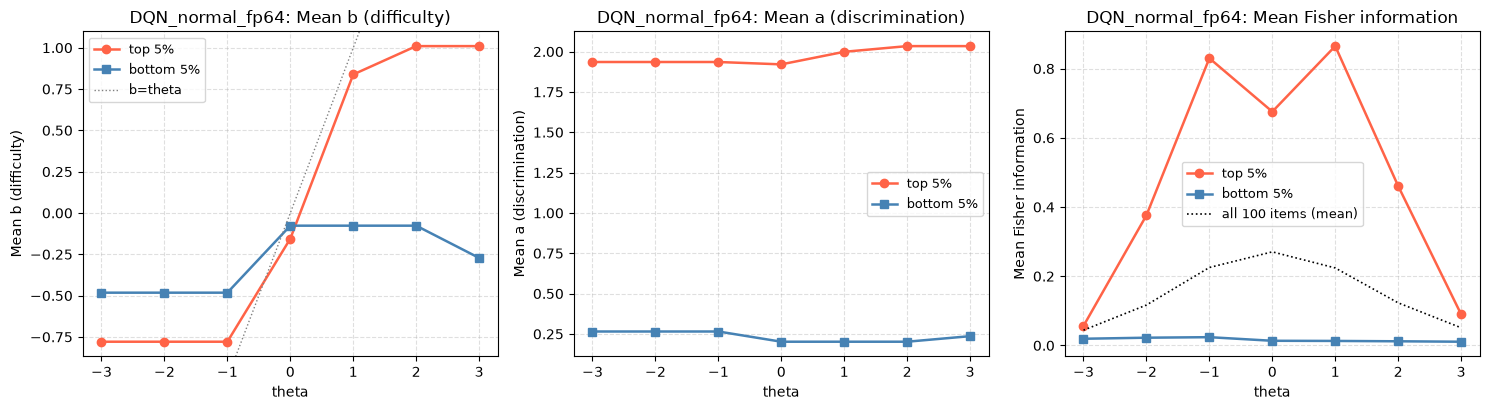

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_top_bottom_2pl_1_100items_DQN_normal_fp64.png


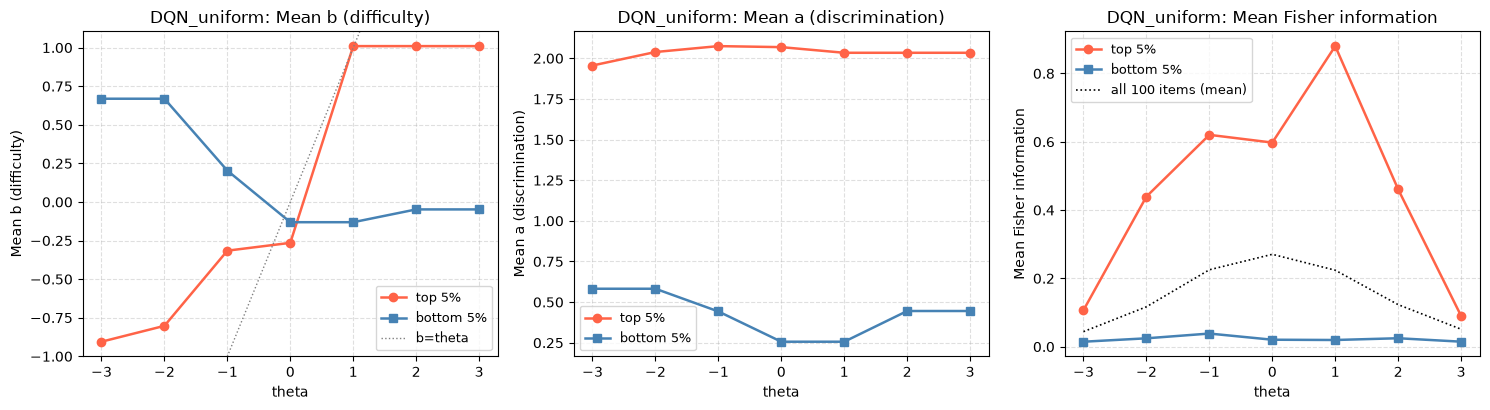

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_top_bottom_2pl_1_100items_DQN_uniform.png


In [15]:
# Separate top/bottom figures per model.
metrics = [
    ("b_mean", "Mean b (difficulty)"),
    ("a_mean", "Mean a (discrimination)"),
    ("FI_mean", "Mean Fisher information"),
]
colors = {"top": "tomato", "bottom": "steelblue"}
markers = {"top": "o", "bottom": "s"}


def plot_top_bottom(model_name: str):
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 4.2), sharex=True)
    subset = summary[summary["model"] == model_name]

    for ax, (column, ylabel) in zip(axes, metrics):
        for group in ("top", "bottom"):
            data = subset[subset["group"] == group]
            ax.plot(
                data["theta"],
                data[column],
                marker=markers[group],
                color=colors[group],
                label=f"{group} {TOP_FRAC:.0%}",
                linewidth=1.8,
            )
        if column == "FI_mean":
            ax.plot(
                subset[subset["group"] == "top"]["theta"],
                subset[subset["group"] == "top"]["all_FI_mean"],
                color="black", linestyle=":", linewidth=1.2,
                label=f"all {ACTION_SPACE} items (mean)",
            )
        if column == "b_mean":
            ax.axline((0, 0), slope=1, color="gray", linestyle=":", linewidth=1.0, label="b=theta")
        ax.set_title(f"{model_name}: {ylabel}")
        ax.set_xlabel("theta")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize=9)

    fig.tight_layout()
    plot_path = RESULTS_DIR / f"analysis_q_top_bottom_2pl_{BANK_ID}_{N_ITEMS}items_{model_name}.png"
    fig.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved: {plot_path}")


for model_name in models:
    plot_top_bottom(model_name)

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_fi_top_bottom_2pl_1_100items_MFI.csv
model  theta  group  n  a_mean  a_std  b_mean  b_std  FI_mean  FI_median  FI_max  FI_min  all_FI_mean
  MFI -3.000    top  5   1.362  0.248  -1.645  0.312    0.217      0.212   0.284   0.122        0.044
  MFI -3.000 bottom  5   1.474  0.843   1.099  0.970    0.001      0.001   0.002   0.000        0.044
  MFI -2.000    top  5   1.722  0.544  -1.541  0.381    0.569      0.480   0.938   0.341        0.117
  MFI -2.000 bottom  5   1.123  0.998   0.777  1.212    0.004      0.003   0.007   0.001        0.117
  MFI -1.000    top  5   1.930  0.382  -0.853  0.334    0.842      0.696   1.336   0.669        0.225
  MFI -1.000 bottom  5   0.203  0.131   0.465  1.161    0.012      0.007   0.026   0.001        0.225
  MFI  0.000    top  5   1.818  0.261  -0.133  0.414    0.727      0.649   1.035   0.632        0.270
  MFI  0.000 bottom  5  

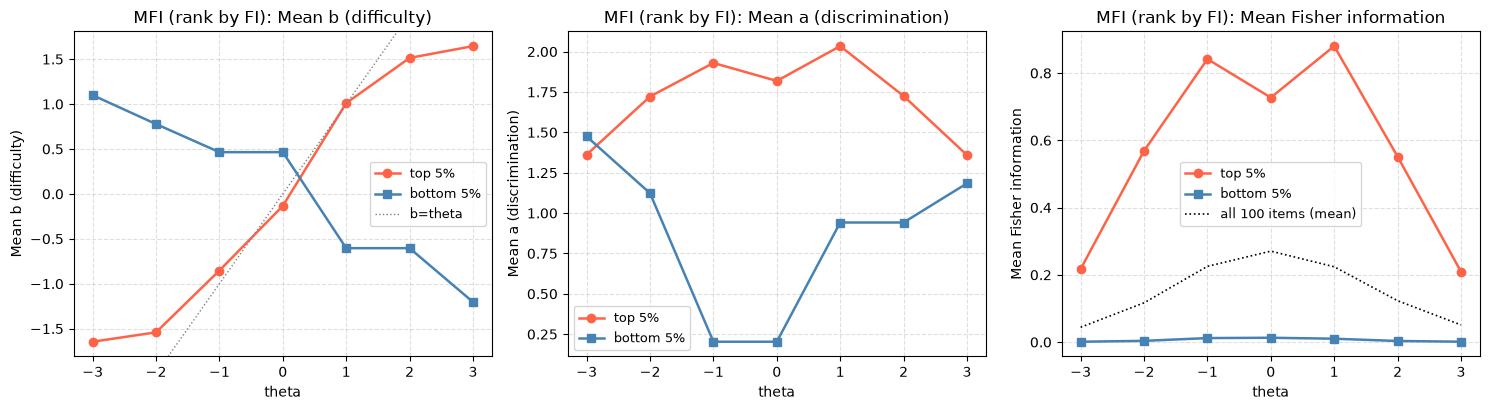

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_fi_top_bottom_2pl_1_100items_MFI.png


In [16]:
# MFI version: rank items by Fisher information (not Q values).
# For each theta, take the top 5% / bottom 5% items by FI(theta) and show
# their mean (a, b, FI). This mirrors MFI's actual selection rule (argmax FI).
mfi_records = []
mfi_all_fi_by_theta: dict[float, np.ndarray] = {}
for theta in THETAS:
    fi = FI_2pl(item_bank, theta)
    mfi_all_fi_by_theta[theta] = fi
    k = max(1, int(round(len(fi) * TOP_FRAC)))
    order = np.argsort(fi)  # ascending
    groups = {"top": order[-k:], "bottom": order[:k]}
    for group, idx in groups.items():
        row = {"model": "MFI", "theta": theta, "group": group}
        row.update(describe_group(item_bank, fi, idx))
        row["all_FI_mean"] = fi.mean()
        mfi_records.append(row)

mfi_summary = pd.DataFrame(mfi_records)[
    ["model", "theta", "group", "n",
     "a_mean", "a_std", "b_mean", "b_std",
     "FI_mean", "FI_median", "FI_max", "FI_min", "all_FI_mean"]
]

mfi_csv = RESULTS_DIR / f"analysis_fi_top_bottom_2pl_{BANK_ID}_{N_ITEMS}items_MFI.csv"
mfi_summary.to_csv(mfi_csv, index=False)
print(f"Saved: {mfi_csv}")
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(mfi_summary.to_string(index=False, float_format="{:.3f}".format))


def plot_mfi_top_bottom():
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 4.2), sharex=True)

    for ax, (column, ylabel) in zip(axes, metrics):
        for group in ("top", "bottom"):
            data = mfi_summary[mfi_summary["group"] == group]
            ax.plot(
                data["theta"],
                data[column],
                marker=markers[group],
                color=colors[group],
                label=f"{group} {TOP_FRAC:.0%}",
                linewidth=1.8,
            )
        if column == "FI_mean":
            ax.plot(
                mfi_summary[mfi_summary["group"] == "top"]["theta"],
                mfi_summary[mfi_summary["group"] == "top"]["all_FI_mean"],
                color="black", linestyle=":", linewidth=1.2,
                label=f"all {ACTION_SPACE} items (mean)",
            )
        if column == "b_mean":
            ax.axline((0, 0), slope=1, color="gray", linestyle=":", linewidth=1.0, label="b=theta")
        ax.set_title(f"MFI (rank by FI): {ylabel}")
        ax.set_xlabel("theta")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize=9)

    fig.tight_layout()
    plot_path = RESULTS_DIR / f"analysis_fi_top_bottom_2pl_{BANK_ID}_{N_ITEMS}items_MFI.png"
    fig.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved: {plot_path}")


plot_mfi_top_bottom()

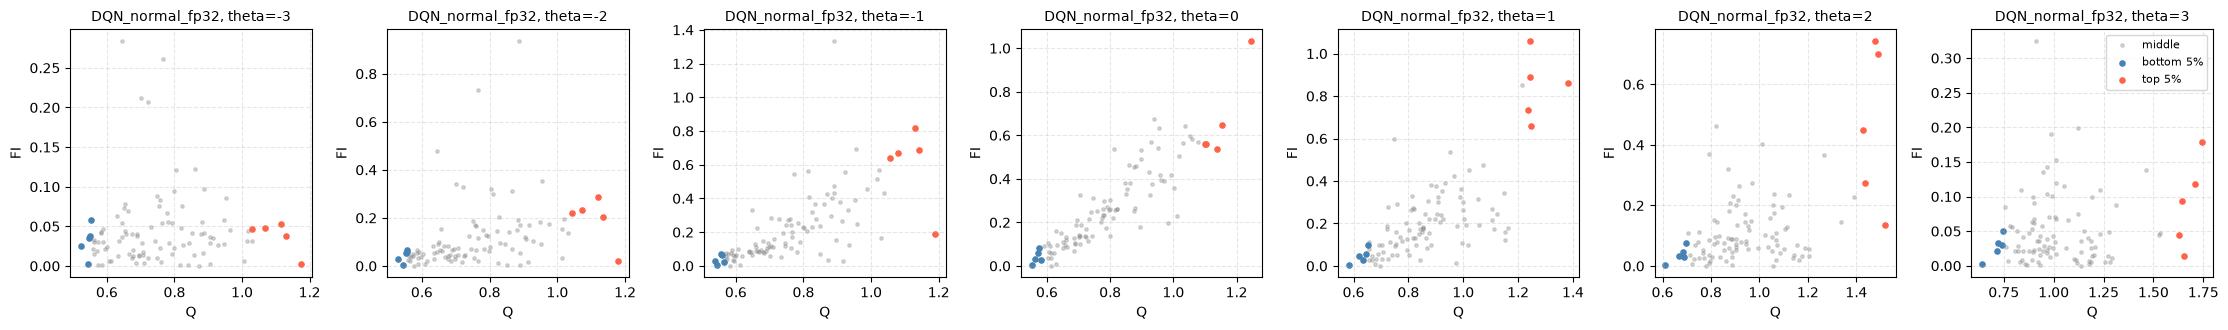

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_vs_fi_scatter_2pl_1_100items_DQN_normal_fp32.png


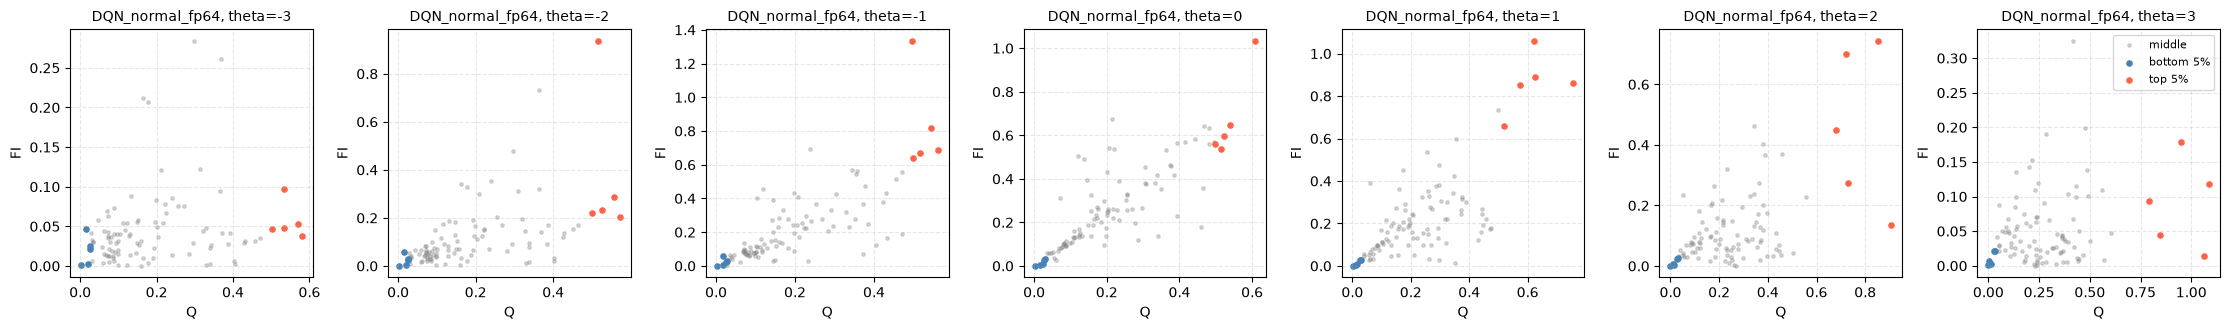

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_vs_fi_scatter_2pl_1_100items_DQN_normal_fp64.png


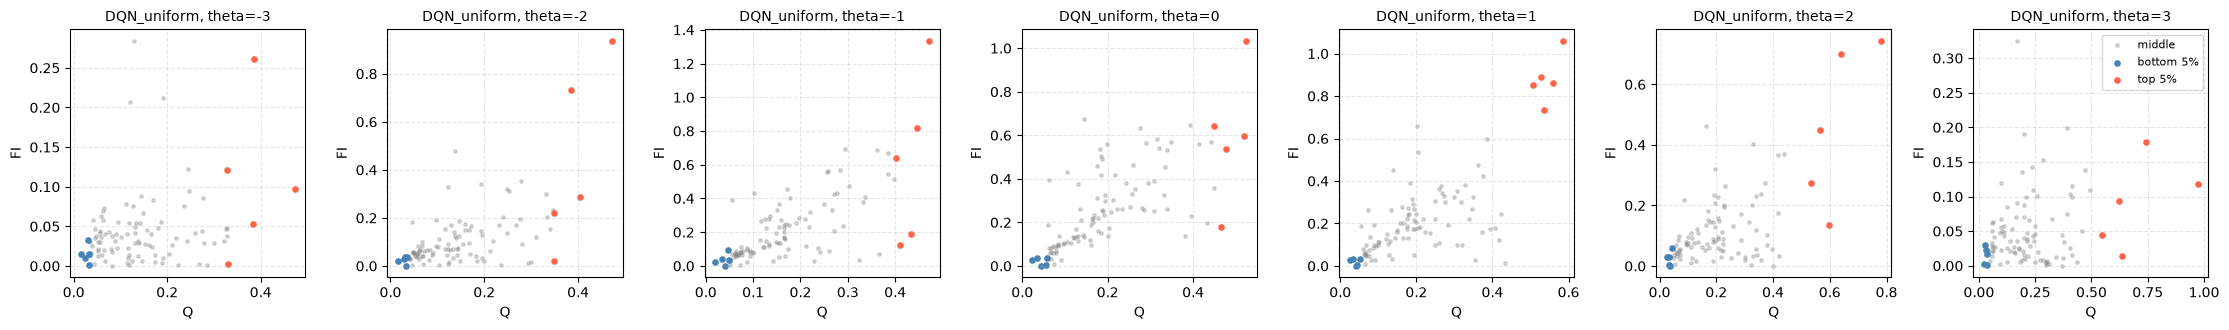

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v2/results/analysis_q_vs_fi_scatter_2pl_1_100items_DQN_uniform.png


In [17]:
# Separate Q vs FI scatter figures per model.
def plot_scatter(model_name: str):
    fig, axes = plt.subplots(1, len(THETAS), figsize=(3.2 * len(THETAS), 3.4), squeeze=False)
    axes = axes[0]

    for ax, theta in zip(axes, THETAS):
        result = raw_by_model_theta[(model_name, theta)]
        q = result["q"]
        fi = result["fi"]
        top_idx = result["top_idx"]
        bottom_idx = result["bottom_idx"]
        mid_mask = np.ones_like(q, dtype=bool)
        mid_mask[top_idx] = False
        mid_mask[bottom_idx] = False

        ax.scatter(q[mid_mask], fi[mid_mask], s=6, alpha=0.3, color="gray", label="middle")
        ax.scatter(q[bottom_idx], fi[bottom_idx], s=14, color="steelblue", label=f"bottom {TOP_FRAC:.0%}")
        ax.scatter(q[top_idx],    fi[top_idx],    s=14, color="tomato",    label=f"top {TOP_FRAC:.0%}")
        ax.set_title(f"{model_name}, theta={theta:g}", fontsize=10)
        ax.set_xlabel("Q")
        ax.set_ylabel("FI")
        ax.grid(True, linestyle="--", alpha=0.3)
        if theta == THETAS[-1]:
            ax.legend(fontsize=8, loc="best")

    fig.tight_layout()
    scatter_path = RESULTS_DIR / f"analysis_q_vs_fi_scatter_2pl_{BANK_ID}_{N_ITEMS}items_{model_name}.png"
    fig.savefig(scatter_path, dpi=150)
    plt.show()
    print(f"Saved: {scatter_path}")


for model_name in models:
    plot_scatter(model_name)